In [9]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional
import napari
from magicgui import magicgui
from magicgui.widgets import Container, TextEdit
from liffile import LifFile

from skimage import util
from skimage.io import imread
from skimage.filters import threshold_triangle, median, sobel, gaussian, threshold_yen
from skimage.measure import label, regionprops_table, regionprops, moments_central
from skimage.morphology import disk, remove_small_objects, remove_small_holes, erosion, closing
from skimage.transform import ProjectiveTransform, warp, probabilistic_hough_line
from scipy.ndimage import rotate, binary_dilation
from skimage.draw import line
import tifffile

In [10]:
class FindInFocusPlaneLite:
    def __init__(
        self,
        lif_path,
        image_index=0,
        downsample=4,
        n_sampling=20,
        patch=50,
        channel_axis=None,
    ):
        self.lif_path = Path(lif_path)
        self.image_index = int(image_index)
        self.downsample = int(downsample)
        self.n_sampling = int(n_sampling)
        self.patch = int(patch)
        self.channel_axis = channel_axis
        self._loaded = False

    def _to_gray(self, im):
        if im.ndim == 2:
            return im
        return np.mean(im, axis=-1)

    def _normalize_stack(self, arr):
        if arr.ndim == 2:
            stack = arr[np.newaxis, ...]
        elif arr.ndim == 3:
            if arr.shape[0] < 64:
                stack = arr
            else:
                stack = arr[np.newaxis, ...]
        elif arr.ndim == 4:
            if self.channel_axis is not None and self.channel_axis != 3:
                stack = np.moveaxis(arr, self.channel_axis, -1)
            else:
                stack = arr
        else:
            raise ValueError(f"Unsupported array shape: {arr.shape}")
        return stack

    def load(self):
        with LifFile(self.lif_path) as lif:
            if self.image_index < 0 or self.image_index >= len(lif.images):
                raise IndexError("image_index out of range")
            img = lif.images[self.image_index]
            image = img.asarray()

        arr = np.asarray(image)
        stack = self._normalize_stack(arr)

        self.stack = stack
        self.nz, self.ny, self.nx = stack.shape[:3]

        ds = max(1, self.downsample)
        if ds > 1:
            if self.stack.ndim == 3:
                self.stack_ds = self.stack[:, ::ds, ::ds]
            else:
                self.stack_ds = self.stack[:, ::ds, ::ds, ...]
        else:
            self.stack_ds = self.stack

        self._loaded = True

    def focus_score(self, patch):
        p = np.asarray(self._to_gray(patch), dtype=float)
        s = sobel(p)
        return float(np.std(s))

    def best_focus_slice(self, stack_zyx, mask=None):
        Z = stack_zyx.shape[0]
        scores = []
        for z in range(Z):
            sl = self._to_gray(stack_zyx[z])
            if mask is not None:
                sl = sl * mask
            scores.append(np.std(sobel(sl)))
        z0 = int(np.argmax(scores))
        return z0, self._to_gray(stack_zyx[z0])

    def curved_plane_refocus(self, stack_zyx, grid=None, patch=None, mask=None):
        if grid is None:
            grid = self.n_sampling
        if patch is None:
            patch = self.patch
        Z, H, W = stack_zyx.shape
        ys = np.linspace(patch // 2, H - patch // 2 - 1, grid).astype(int)
        xs = np.linspace(patch // 2, W - patch // 2 - 1, grid).astype(int)

        pts, zs = [], []
        for y in ys:
            for x in xs:
                if mask is not None and not mask[y, x]:
                    continue
                sl = (slice(y - patch // 2, y + patch // 2), slice(x - patch // 2, x + patch // 2))
                f = np.array([self.focus_score(stack_zyx[z][sl]) for z in range(Z)], dtype=np.float32)
                pts.append((x, y))
                zs.append(int(np.argmax(f)))

        if len(zs) < 6:
            z0, img = self.best_focus_slice(stack_zyx, mask=mask)
            zmap = np.full(stack_zyx.shape[1:], z0, dtype=np.int16)
            return img, zmap, np.array(pts), np.array(zs)

        pts = np.array(pts, dtype=np.float32)
        zs = np.array(zs, dtype=np.float32)

        Xc = pts[:, 0] - pts[:, 0].mean()
        Yc = pts[:, 1] - pts[:, 1].mean()
        scale = max(W, H)
        Xn = Xc / scale
        Yn = Yc / scale

        B = np.column_stack((Xn**2, Yn**2, Xn * Yn, Xn, Yn, np.ones_like(Xn)))
        coeffs, *_ = np.linalg.lstsq(B, zs, rcond=None)

        Xg, Yg = np.meshgrid(np.arange(W), np.arange(H))
        mean_x = pts[:, 0].mean()
        mean_y = pts[:, 1].mean()
        Xg_n = (Xg - mean_x) / scale
        Yg_n = (Yg - mean_y) / scale
        zmap = (
            coeffs[0] * Xg_n**2
            + coeffs[1] * Yg_n**2
            + coeffs[2] * Xg_n * Yg_n
            + coeffs[3] * Xg_n
            + coeffs[4] * Yg_n
            + coeffs[5]
        )
        zmap = np.clip(np.rint(zmap).astype(np.int16), 0, Z - 1)
        img = np.take_along_axis(stack_zyx, zmap[None, :, :], axis=0)[0]
        return img, zmap, pts, zs

    def compute_grid_and_focus(self):
        if not self._loaded:
            self.load()

        if self.stack_ds.ndim == 4:
            stack_ds_score = np.mean(self.stack_ds, axis=-1)
        else:
            stack_ds_score = self.stack_ds

        focus_ds, grid_ds, pts, zs = self.curved_plane_refocus(
            stack_ds_score,
            grid=self.n_sampling,
            patch=self.patch,
            mask=None,
        )

        self.grid_ds = np.clip(grid_ds, 0, self.nz - 1)
        if self.stack_ds.ndim == 3:
            self.focus_ds_out = np.take_along_axis(self.stack_ds, self.grid_ds[None, :, :], axis=0)[0]
        else:
            self.focus_ds_out = np.take_along_axis(self.stack_ds, self.grid_ds[None, :, :, None], axis=0)[0]

        return self.focus_ds_out, self.grid_ds, pts, zs

    def run(self):
        focus_ds, _, _, _ = self.compute_grid_and_focus()
        return focus_ds


class DeviceSegmentationApp:
    def __init__(
        self,
        low_frac: float = 0.82,
        high_frac: float = 1.10,
        smooth_window: int = 5,
        bin_size: float = 2.0,
        min_run_frac: float = 0.25,
        typical_pct: float = 50.0,
        line_length: int = 400,
        line_gap: int = 900,
        hough_threshold: int = 70,
        mask_sigma: float = 2.0,
        mask_frac_thresh: float = 0.70,
    ):
        self.low_frac = low_frac
        self.high_frac = high_frac
        self.smooth_window = smooth_window
        self.bin_size = bin_size
        self.min_run_frac = min_run_frac
        self.typical_pct = typical_pct
        self.line_length = line_length
        self.line_gap = line_gap
        self.hough_threshold = hough_threshold
        self.mask_sigma = mask_sigma
        self.mask_frac_thresh = mask_frac_thresh

        self.viewer = napari.Viewer()
        self._selected_image_folder: Optional[Path] = None
        self._selected_lif: Optional[Path] = None
        self._image_paths = []
        self._image_choice_map = {}
        self._roi_layer = None
        self._cropped_layer = None
        self._cropped_edge_layer = None
        self._last_image = None
        self._last_image_path = None
        self._last_edge_margin_um = None
        self._last_see_interim_layers = True

        self.images_output = TextEdit(value="")
        try:
            self.images_output.native.setReadOnly(True)
        except Exception:
            pass
        self.images_output.min_height = 120
        self.images_output.max_height = 300

        @magicgui(
            image_source={"label": "Folder/.tif/.lif", "mode": "r"},
            call_button="Load images",
        )
        def list_images(image_source: Path = Path()):
            self._list_images(image_source)

        @magicgui(
            image_choice={"label": "Image", "choices": ["(load images)"], "widget_type": "ComboBox"},
            focus_downsample={"label": "LIF downsample", "min": 1, "max": 16, "step": 1},
            focus_n_sampling={"label": "LIF n_sampling", "min": 4, "max": 100, "step": 1},
            focus_patch={"label": "LIF patch", "min": 5, "max": 512, "step": 1},
            mask_central_region={"label": "Mask central region"},
            edge_margin_um={"label": "Edge margin (um)", "min": 0.0, "max": 10000.0, "step": 1.0},
            see_interim_layers={"label": "See interim layers (debug)"},
            clear_layers={"label": "Clear viewer first"},
            call_button="Segment + View",
        )
        def segment_and_view(
            image_choice: str = "(load images)",
            focus_downsample: int = 4,
            focus_n_sampling: int = 20,
            focus_patch: int = 50,
            mask_central_region: bool = False,
            edge_margin_um: float = 0.0,
            see_interim_layers: bool = True,
            clear_layers: bool = False,
        ):
            self._segment_and_view(
                image_choice=image_choice,
                focus_downsample=focus_downsample,
                focus_n_sampling=focus_n_sampling,
                focus_patch=focus_patch,
                mask_central_region=mask_central_region,
                edge_margin_um=edge_margin_um,
                see_interim_layers=see_interim_layers,
                clear_layers=clear_layers,
            )

        @magicgui(call_button="Create cropped aligned")
        def apply_crop():
            self._apply_crop_from_roi()

        self.list_images = list_images
        self.segment_and_view = segment_and_view
        self.apply_crop = apply_crop
        self.main_panel = Container(
            widgets=[self.list_images, self.segment_and_view, self.apply_crop, self.images_output]
        )
        self.viewer.window.add_dock_widget(self.main_panel, area="right")

        self.segment_and_view.image_choice.changed.connect(self._update_segment_button)
        self.segment_and_view.call_button.enabled = False
        self._update_segment_button()

    def _order_corners_clockwise(self, corners_xy: np.ndarray):
        c = np.asarray(corners_xy, dtype=float)
        centroid = c.mean(axis=0)
        angles = np.arctan2(c[:, 1] - centroid[1], c[:, 0] - centroid[0])
        order = np.argsort(angles)
        c = c[order]
        start = np.argmin(c[:, 0] + c[:, 1])
        c = np.roll(c, -start, axis=0)
        return c

    def _crop_rectified_from_corners(self, in_focus_plane: np.ndarray, corners_xy: np.ndarray):
        if corners_xy is None:
            return None
        c = self._order_corners_clockwise(corners_xy)
        w1 = np.hypot(c[1, 0] - c[0, 0], c[1, 1] - c[0, 1])
        w2 = np.hypot(c[2, 0] - c[3, 0], c[2, 1] - c[3, 1])
        h1 = np.hypot(c[3, 0] - c[0, 0], c[3, 1] - c[0, 1])
        h2 = np.hypot(c[2, 0] - c[1, 0], c[2, 1] - c[1, 1])
        width = int(max(w1, w2))
        height = int(max(h1, h2))
        if width <= 1 or height <= 1:
            return None
        dst = np.array(
            [
                [0, 0],
                [width - 1, 0],
                [width - 1, height - 1],
                [0, height - 1],
            ],
            dtype=float,
        )
        tform = ProjectiveTransform()
        if not tform.estimate(dst, c):
            return None
        warped = warp(in_focus_plane, tform, output_shape=(height, width), order=1, preserve_range=True)
        return warped.astype(in_focus_plane.dtype)

    def _pixel_size_um_from_tiff(self, image_path):
        if image_path is None:
            return None
        tags = tifffile.TiffFile(str(image_path)).pages[0].tags
        xres = tags.get("XResolution")
        yres = tags.get("YResolution")
        if xres is None and yres is None:
            return None

        def _res_to_float(tag):
            if tag is None:
                return None
            val = tag.value
            if isinstance(val, tuple) and len(val) == 2:
                num, den = val
                if den == 0:
                    return None
                return float(num) / float(den)
            return float(val)

        xres = _res_to_float(xres)
        yres = _res_to_float(yres)
        res_unit = tags.get("ResolutionUnit")
        res_unit = res_unit.value if res_unit is not None else None
        if res_unit == 2:
            unit_um = 25400.0
        elif res_unit == 3:
            unit_um = 10000.0
        else:
            return None
        px_per_unit = np.mean([v for v in (xres, yres) if v is not None])
        if px_per_unit <= 0:
            return None
        return unit_um / px_per_unit

    def _corners_touch_border(self, corners_xy: np.ndarray, shape, margin=0):
        H, W = shape
        x = corners_xy[:, 0]
        y = corners_xy[:, 1]
        return (
            (x <= margin).any()
            or (x >= (W - 1 - margin)).any()
            or (y <= margin).any()
            or (y >= (H - 1 - margin)).any()
        )

    def _signed_orientation(self, region):
        img = region.image.astype(float)
        mu = moments_central(img)
        y20 = mu[2, 0]
        y02 = mu[0, 2]
        y11 = mu[1, 1]
        angle_rad = 0.5 * np.arctan2(2 * y11, y20 - y02)
        return np.rad2deg(angle_rad)

    def _mask_out_organoid(self, in_focus_plane):
        inverted = gaussian(util.invert(in_focus_plane), sigma=self.mask_sigma)
        H, W = in_focus_plane.shape[:2]
        xy_area = H * W
        cyi = H // 2
        cxi = W // 2
        r = int(min(H, W) * 0.1)
        yy, xx = np.ogrid[:H, :W]
        central_roi = (yy - cyi) ** 2 + (xx - cxi) ** 2 <= r**2

        def score(p):
            overlap = np.sum(labelled[central_roi] == p.label)
            py, px = p.centroid
            dist2 = (py - cyi) ** 2 + (px - cxi) ** 2
            return (-overlap, dist2)

        thresh = threshold_yen(inverted)
        labelled = label(inverted > thresh)
        props = regionprops(labelled)
        if len(props) == 0:
            return np.zeros((H, W), dtype=bool)
        best_prop = min(props, key=score)
        if (best_prop.area > xy_area * self.mask_frac_thresh) or (best_prop.solidity < 0.5):
            print("TOO BIG, RETRYING WITH TRIANGLE THRESH")
            thresh = threshold_triangle(inverted)
            labelled = label(inverted > thresh)
            props = regionprops(labelled)
            if len(props) == 0:
                return np.zeros((H, W), dtype=bool)
            best_prop = min(props, key=score)
        organoid_region = labelled == best_prop.label
        organoid_region = remove_small_holes(organoid_region, area_threshold=50000)
        organoid_region = closing(organoid_region, disk(5))
        return organoid_region

    def _oriented_rect_corners_crop_necks_and_flares(self, mask: np.ndarray):
        ys, xs = np.nonzero(mask)
        if xs.size == 0:
            return None, None, None

        cx, cy = xs.mean(), ys.mean()
        centroid_xy = np.array([cx, cy], float)

        mu = moments_central(mask.astype(np.uint8))
        mu20_y = mu[2, 0]
        mu02_x = mu[0, 2]
        mu11 = mu[1, 1]
        angle_rad = 0.5 * np.arctan2(2 * mu11, (mu02_x - mu20_y))

        c, s = np.cos(angle_rad), np.sin(angle_rad)
        dx = xs - cx
        dy = ys - cy
        u = c * dx + s * dy
        v = -s * dx + c * dy

        u_span = float(u.max() - u.min())
        v_span = float(v.max() - v.min())
        if v_span >= u_span:
            long = v
            short = u
            long_name = "v"
        else:
            long = u
            short = v
            long_name = "u"

        short_min_full = float(short.min())
        short_max_full = float(short.max())
        long_bin = np.floor(long / self.bin_size).astype(int)
        bins, inv = np.unique(long_bin, return_inverse=True)

        short_min = np.full(bins.shape, np.inf)
        short_max = np.full(bins.shape, -np.inf)
        np.minimum.at(short_min, inv, short)
        np.maximum.at(short_max, inv, short)
        widths = short_max - short_min

        if self.smooth_window and self.smooth_window > 1:
            w = int(self.smooth_window)
            if w % 2 == 0:
                w += 1
            pad = w // 2
            widths_pad = np.pad(widths, (pad, pad), mode="edge")
            widths_s = np.convolve(widths_pad, np.ones(w) / w, mode="valid")
        else:
            widths_s = widths

        typical_width = float(np.percentile(widths_s, self.typical_pct))
        low_thr = self.low_frac * typical_width
        high_thr = self.high_frac * typical_width

        too_thin = widths_s < low_thr
        too_wide = widths_s > high_thr
        keep = (~too_thin) & (~too_wide)

        best_start = best_end = None
        best_len = 0
        cur_start = cur_end = None

        for i in range(len(bins)):
            if not keep[i]:
                if cur_start is not None:
                    L = cur_end - cur_start + 1
                    if L > best_len:
                        best_len = L
                        best_start, best_end = cur_start, cur_end
                cur_start = cur_end = None
                continue
            if cur_start is None:
                cur_start = cur_end = bins[i]
            else:
                if bins[i] == cur_end + 1:
                    cur_end = bins[i]
                else:
                    L = cur_end - cur_start + 1
                    if L > best_len:
                        best_len = L
                        best_start, best_end = cur_start, cur_end
                    cur_start = cur_end = bins[i]

        if cur_start is not None:
            L = cur_end - cur_start + 1
            if L > best_len:
                best_len = L
                best_start, best_end = cur_start, cur_end

        total_len_bins = int(bins.max() - bins.min() + 1)
        min_run_bins = int(np.ceil(self.min_run_frac * total_len_bins))

        if best_start is None or best_len < min_run_bins:
            long_min = float(long.min())
            long_max = float(long.max())
            crop_width = False
        else:
            long_min = float(best_start * self.bin_size)
            long_max = float((best_end + 1) * self.bin_size)
            band_mask_bins = (bins >= best_start) & (bins <= best_end)
            has_wide_outside = bool(np.any(too_wide & (~band_mask_bins)))
            crop_width = bool(has_wide_outside)

        in_long_band = (long >= long_min) & (long <= long_max)
        if crop_width:
            short_min_use = float(short[in_long_band].min())
            short_max_use = float(short[in_long_band].max())
        else:
            short_min_use = short_min_full
            short_max_use = short_max_full

        if long_name == "v":
            umin, umax = short_min_use, short_max_use
            vmin, vmax = long_min, long_max
        else:
            umin, umax = long_min, long_max
            vmin, vmax = short_min_use, short_max_use

        corners_uv = np.array([[umin, vmin], [umax, vmin], [umax, vmax], [umin, vmax]], dtype=float)
        x = cx + c * corners_uv[:, 0] - s * corners_uv[:, 1]
        y = cy + s * corners_uv[:, 0] + c * corners_uv[:, 1]
        corners_xy = np.stack([x, y], axis=1)
        return corners_xy, angle_rad, centroid_xy

    def _segment_from_plane(
        self,
        in_focus_plane: np.ndarray,
        mask_central_region: bool,
        edge_margin_um: Optional[float],
        image_path_for_pixel_size: Optional[Path],
        to_plot: bool,
        return_debug: bool,
    ):
        flag = False
        median_thresholded = median(in_focus_plane, footprint=disk(7))
        sobel_operated = sobel(median_thresholded)
        thresh = threshold_triangle(sobel_operated)
        binary = sobel_operated > thresh

        h, w = in_focus_plane.shape[:2]
        h3 = h // 3
        w3 = w // 3
        binary[h3:2 * h3, w3:2 * w3] = 0

        organoid_region = None
        if mask_central_region:
            organoid_region = self._mask_out_organoid(in_focus_plane)
            binary[organoid_region] = 0

        labels = label(binary)
        data = regionprops_table(labels, binary, properties=("label", "area", "eccentricity"))
        condition = (data["area"] > 100) & (data["eccentricity"] > 0.5)
        labels_to_dilate = util.map_array(labels, data["label"], data["label"] * condition)
        dilated_output = np.zeros_like(labels, dtype=np.uint8)

        base_selem = np.zeros((31, 31), dtype=bool)
        base_selem[15, :] = 1
        pad = base_selem.shape[0] // 2
        for region in regionprops(labels_to_dilate):
            angle_to_rotate = self._signed_orientation(region)
            rotated_selem = rotate(base_selem.astype(float), angle=90 + angle_to_rotate, reshape=False, order=0) > 0.5

            minr, minc, maxr, maxc = region.bbox
            r0 = max(minr - pad, 0)
            r1 = min(maxr + pad, labels_to_dilate.shape[0])
            c0 = max(minc - pad, 0)
            c1 = min(maxc + pad, labels_to_dilate.shape[1])

            mask_roi = labels_to_dilate[r0:r1, c0:c1] == region.label
            dilated = binary_dilation(mask_roi, structure=rotated_selem)
            dilated_view = dilated_output[r0:r1, c0:c1]
            dilated_view[dilated] = 255

        post_dilation_mask = np.logical_or(dilated_output, binary)

        clean_labels = label(~post_dilation_mask)
        props = regionprops(clean_labels)
        largest_prop = max(props, key=lambda p: p.area)
        device_mask = clean_labels == largest_prop.label

        edges = None
        reconstructed = None
        reconstructed_mask = None
        new_corners = None
        new_angle_rad = None
        new_centroid_xy = None
        corners, angle_rad, centroid_xy = self._oriented_rect_corners_crop_necks_and_flares(device_mask)
        if corners is None or self._corners_touch_border(corners, device_mask.shape, margin=5):
            flag = True
            edges = remove_small_objects(labels_to_dilate > 0)
            segs = probabilistic_hough_line(
                edges,
                line_length=self.line_length,
                line_gap=self.line_gap,
                threshold=self.hough_threshold,
            )
            reconstructed = np.zeros_like(edges, dtype=bool)
            for (x0, y0), (x1, y1) in segs:
                rr, cc = line(y0, x0, y1, x1)
                reconstructed[rr, cc] = True

            reconstructed_mask = np.logical_or(reconstructed, post_dilation_mask)
            updated_clean_labels = label(~reconstructed_mask)
            props = regionprops(updated_clean_labels)

            areas = sorted((p.area for p in props), reverse=True)
            largest = areas[0] if len(areas) > 0 else 0
            second = areas[1] if len(areas) > 1 else 0

            if largest > 0 and (second / largest) > 0.5:
                print("RETRYING WITH EROSION FALLBACK (2nd/1st area ratio too high)")
                plt.imshow(updated_clean_labels, cmap="jet")
                updated_clean_labels = label(erosion(~reconstructed_mask, disk(1)))
                props = regionprops(updated_clean_labels)
            largest_prop = max(props, key=lambda p: p.area)
            new_device_mask = updated_clean_labels == largest_prop.label

            new_corners, new_angle_rad, new_centroid_xy = self._oriented_rect_corners_crop_necks_and_flares(
                new_device_mask
            )
        if flag:
            final_corners = new_corners
            final_angle_rad = new_angle_rad
            final_centroid_xy = new_centroid_xy
        else:
            final_corners = corners
            final_angle_rad = angle_rad
            final_centroid_xy = centroid_xy

        cropped_rotated = self._crop_rectified_from_corners(in_focus_plane, final_corners)
        cropped_rotated_edge = None
        show_edge_crop = edge_margin_um is not None and edge_margin_um > 0 and cropped_rotated is not None
        if show_edge_crop:
            pixel_size_um = None
            if image_path_for_pixel_size is not None and Path(image_path_for_pixel_size).suffix.lower() in (
                ".tif",
                ".tiff",
            ):
                pixel_size_um = self._pixel_size_um_from_tiff(image_path_for_pixel_size)
            if pixel_size_um is not None:
                margin_px = int(round(edge_margin_um / pixel_size_um))
                if margin_px <= 0:
                    cropped_rotated_edge = cropped_rotated
                else:
                    h, w = cropped_rotated.shape[:2]
                    if (h > 2 * margin_px) and (w > 2 * margin_px):
                        cropped_rotated_edge = cropped_rotated[margin_px:-margin_px, margin_px:-margin_px]

        if to_plot:
            fig, ax = plt.subplots(
                ncols=9 + (3 * flag) + mask_central_region + show_edge_crop,
                figsize=(22, 5),
            )
            ax[0].imshow(in_focus_plane, interpolation="none", cmap="gray")
            ax[1].imshow(sobel_operated, interpolation="none", cmap="gray")
            ax[2].imshow(binary, interpolation="none", cmap="gray")
            ax[3].imshow(labels_to_dilate, interpolation="none", cmap="jet")
            ax[4].imshow(post_dilation_mask, interpolation="none", cmap="gray")
            ax[5].imshow(device_mask, interpolation="none", cmap="gray")

            ax[6].imshow(in_focus_plane, alpha=0.7, cmap="gray", interpolation="none")
            ax[6].imshow(
                np.ma.masked_where(device_mask == 0, post_dilation_mask),
                cmap="jet",
                alpha=0.5,
                interpolation="none",
            )

            ax[7].imshow(in_focus_plane, alpha=0.7, cmap="gray", interpolation="none")
            ax[7].plot(
                np.r_[final_corners[:, 0], final_corners[0, 0]],
                np.r_[final_corners[:, 1], final_corners[0, 1]],
                "-r",
                linewidth=2,
            )

            cx, cy = final_centroid_xy
            ax[7].plot(cx, cy, "xg", markersize=10, mew=2)
            L = 150
            dx = L * np.cos(final_angle_rad)
            dy = L * np.sin(final_angle_rad)
            ax[7].plot([cx - dx, cx + dx], [cy - dy, cy + dy], "-g", lw=2)

            if flag:
                ax[8].imshow(edges, cmap="gray")
                ax[9].imshow(np.logical_or(reconstructed, post_dilation_mask), cmap="gray")
                ax[10].imshow(in_focus_plane, alpha=0.7, interpolation="none", cmap="gray")
                ax[10].plot(
                    np.r_[new_corners[:, 0], new_corners[0, 0]],
                    np.r_[new_corners[:, 1], new_corners[0, 1]],
                    "-r",
                    linewidth=2,
                )

                ncx, ncy = new_centroid_xy
                ax[10].plot(ncx, ncy, "xg", markersize=10, mew=2)
                ndx = L * np.cos(new_angle_rad)
                ndy = L * np.sin(new_angle_rad)
                ax[10].plot([ncx - ndx, ncx + ndx], [ncy - ndy, ncy + ndy], "-g", lw=2)
            cropped_idx = 8 + (3 * flag)
            if cropped_rotated is not None:
                ax[cropped_idx].imshow(cropped_rotated, cmap="gray")
            else:
                ax[cropped_idx].text(0.5, 0.5, "No crop", ha="center", va="center")
            if show_edge_crop:
                edge_idx = cropped_idx + 1
                if cropped_rotated_edge is not None:
                    ax[edge_idx].imshow(cropped_rotated_edge, cmap="gray")
                else:
                    ax[edge_idx].text(0.5, 0.5, "No edge crop", ha="center", va="center")
            if mask_central_region:
                ax[-1].imshow(in_focus_plane, cmap="gray")
                ax[-1].imshow(np.ma.masked_where(~organoid_region, organoid_region), cmap="jet", alpha=0.5)
            titles = [
                "Original Image",
                "Sobel",
                "Binarised",
                "Labels to Dilate",
                "Final Mask",
                "Clean Mask",
                "Clean Labels",
                "Overlay",
            ]
            if flag:
                titles += ["Edges", "reconstructedstructed", "Final"]
            titles += ["Cropped + Aligned"]
            if show_edge_crop:
                titles += ["Edge Cropped"]
            if mask_central_region:
                titles += ["Hole Mask"]

            for i, axis in enumerate(ax):
                ax[i].axis("off")
                if i < len(titles):
                    ax[i].set_title(titles[i])
            plt.show()

        if return_debug:
            debug = {
                "median_thresholded": median_thresholded,
                "sobel_operated": sobel_operated,
                "binary": binary,
                "labels_to_dilate": labels_to_dilate,
                "post_dilation_mask": post_dilation_mask,
                "device_mask": device_mask,
                "organoid_region": organoid_region,
                "edges": edges,
                "reconstructed": reconstructed,
                "reconstructed_mask": reconstructed_mask,
                "flag": flag,
                "final_corners": final_corners,
                "final_centroid_xy": final_centroid_xy,
                "final_angle_rad": final_angle_rad,
                "new_corners": new_corners,
                "new_centroid_xy": new_centroid_xy,
                "new_angle_rad": new_angle_rad,
                "cropped_rotated": cropped_rotated,
                "cropped_rotated_edge": cropped_rotated_edge,
            }
            return (in_focus_plane, organoid_region, final_corners, cropped_rotated, cropped_rotated_edge, debug)
        if flag and mask_central_region:
            return (in_focus_plane, organoid_region, final_corners, cropped_rotated, cropped_rotated_edge)
        if flag:
            return (in_focus_plane, None, final_corners, cropped_rotated, cropped_rotated_edge)
        if mask_central_region:
            return (in_focus_plane, organoid_region, final_corners, cropped_rotated, cropped_rotated_edge)
        return (in_focus_plane, None, final_corners, cropped_rotated, cropped_rotated_edge)

    def _focus_plane_from_lif(self, image_index: int, downsample: int, n_sampling: int, patch: int):
        ref = FindInFocusPlaneLite(
            self._selected_lif,
            image_index=image_index,
            downsample=downsample,
            n_sampling=n_sampling,
            patch=patch,
        )
        return ref.run()

    def segment_device(
        self,
        image_paths,
        image_number,
        to_plot=True,
        mask_central_region=False,
        edge_margin_um=None,
        return_debug=False,
    ):
        print(
            "Segmenting image {}, {}".format(
                image_number, image_paths[image_number] if isinstance(image_paths, (list, tuple)) else image_paths
            )
        )

        if isinstance(image_paths, (list, tuple)):
            in_focus_plane = imread(image_paths[image_number]).astype(np.float32)
            image_path_for_pixel_size = image_paths[image_number]
        elif isinstance(image_paths, Path) and image_paths.suffix.lower() == ".lif":
            try:
                with tifffile.LifFile(str(image_paths)) as lif:
                    series = lif.series[image_number]
                    if hasattr(series, "asarray"):
                        arr = series.asarray()
                    else:
                        arr = tifffile.imread(str(image_paths), series=image_number)
                    in_focus_plane = arr.astype(np.float32)
            except Exception:
                arr = tifffile.imread(str(image_paths), key=image_number)
                in_focus_plane = arr.astype(np.float32)
            image_path_for_pixel_size = None
        else:
            in_focus_plane = imread(image_paths[image_number]).astype(np.float32)
            image_path_for_pixel_size = None

        return self._segment_from_plane(
            in_focus_plane,
            mask_central_region,
            edge_margin_um,
            image_path_for_pixel_size,
            to_plot,
            return_debug,
        )

    def _list_images(self, image_source: Path):
        p = Path(image_source)
        if not p.exists():
            self.images_output.value = "[WARN] Please select a folder, a .tif/.tiff file, or a .lif file."
            return

        self._selected_image_folder = None
        self._selected_lif = None
        self._image_paths = []
        choices = []
        choice_map = {}

        if p.is_dir():
            self._selected_image_folder = p
            image_files = sorted(
                [q for q in self._selected_image_folder.iterdir() if q.is_file() and q.suffix.lower() in (".tif", ".tiff")]
            )
            if not image_files:
                self.images_output.value = "[WARN] No .tif/.tiff images found in the selected folder."
                self._image_choice_map = {}
                self.segment_and_view.image_choice.choices = ["(load images)"]
                self.segment_and_view.image_choice.value = "(load images)"
                self._update_segment_button()
                return
            self._image_paths = image_files
            for i, pth in enumerate(image_files):
                label = f"{i}: {pth.name}"
                choices.append(label)
                choice_map[label] = i
            self._image_choice_map = choice_map
            self.segment_and_view.image_choice.choices = choices
            self.segment_and_view.image_choice.value = choices[0]
            self.images_output.value = f"[OK] Found {len(choices)} images in folder. Select one and click Segment + View."
            self._update_segment_button()
            return

        if p.suffix.lower() == ".lif":
            self._selected_lif = p
            try:
                with LifFile(self._selected_lif) as lif:
                    for i, img in enumerate(lif.images):
                        name = None
                        if hasattr(img, "name") and img.name:
                            name = img.name
                        elif hasattr(img, "info") and img.info:
                            name = str(img.info).split("\n")[0]
                        else:
                            name = f"image_{i}"
                        label = f"{i}: {name}"
                        choices.append(label)
                        choice_map[label] = i
            except Exception:
                self.images_output.value = "[ERROR] Unable to read .lif contents (liffile not available or file invalid)."
                self._image_choice_map = {}
                self.segment_and_view.image_choice.choices = ["(load images)"]
                self.segment_and_view.image_choice.value = "(load images)"
                self._update_segment_button()
                return

            if not choices:
                self.images_output.value = "[WARN] No readable images found inside the selected .lif file."
                self._image_choice_map = {}
                self.segment_and_view.image_choice.choices = ["(load images)"]
                self.segment_and_view.image_choice.value = "(load images)"
                self._update_segment_button()
                return

            self._image_choice_map = choice_map
            self.segment_and_view.image_choice.choices = choices
            self.segment_and_view.image_choice.value = choices[0]
            self.images_output.value = f"[OK] Found {len(choices)} images in .lif. Select one and click Segment + View."
            self._update_segment_button()
            return

        if p.suffix.lower() in (".tif", ".tiff"):
            self._image_paths = [p]
            label = f"0: {p.name}"
            choices = [label]
            choice_map[label] = 0
            self._image_choice_map = choice_map
            self.segment_and_view.image_choice.choices = choices
            self.segment_and_view.image_choice.value = choices[0]
            self.images_output.value = "[OK] Loaded single .tif file. Select it and click Segment + View."
            self._update_segment_button()
            return

        self.images_output.value = "[WARN] Unsupported selection. Choose a folder, a .tif/.tiff file, or a .lif file."
        self._image_choice_map = {}
        self.segment_and_view.image_choice.choices = ["(load images)"]
        self.segment_and_view.image_choice.value = "(load images)"
        self._update_segment_button()

    def _segment_and_view(
        self,
        image_choice: str,
        focus_downsample: int,
        focus_n_sampling: int,
        focus_patch: int,
        mask_central_region: bool,
        edge_margin_um: float,
        see_interim_layers: bool,
        clear_layers: bool,
    ):
        source_is_lif = bool(getattr(self, "_selected_lif", None) and self._selected_lif.exists())

        if not source_is_lif and not self._image_paths:
            self.images_output.value = "[WARN] Select a folder/.tif/.lif and click 'Load images' first."
            return
        if not self._image_choice_map:
            self.images_output.value = "[WARN] Click 'Load images' to populate the dropdown."
            return

        image_index = self._image_choice_map.get(image_choice)
        if image_index is None:
            self.images_output.value = "[WARN] Please select an image from the dropdown."
            return

        self.images_output.value = f"[INFO] Segmenting image_index={image_index}..."
        try:
            edge_margin = edge_margin_um if edge_margin_um and edge_margin_um > 0 else None
            if source_is_lif:
                in_focus_plane = self._focus_plane_from_lif(
                    image_index=image_index,
                    downsample=focus_downsample,
                    n_sampling=focus_n_sampling,
                    patch=focus_patch,
                )
                (
                    in_focus_plane,
                    organoid_region,
                    final_corners,
                    cropped_rotated,
                    cropped_rotated_edge,
                    debug,
                ) = self._segment_from_plane(
                    in_focus_plane,
                    mask_central_region,
                    edge_margin,
                    image_path_for_pixel_size=None,
                    to_plot=False,
                    return_debug=True,
                )
                self._last_image_path = self._selected_lif
            else:
                (
                    in_focus_plane,
                    organoid_region,
                    final_corners,
                    cropped_rotated,
                    cropped_rotated_edge,
                    debug,
                ) = self.segment_device(
                    self._image_paths,
                    image_index,
                    to_plot=False,
                    mask_central_region=mask_central_region,
                    edge_margin_um=edge_margin,
                    return_debug=True,
                )
                self._last_image_path = self._image_paths[image_index]
        except Exception as e:
            self.images_output.value = f"[ERROR] Segmentation failed: {type(e).__name__}: {e}"
            return

        if clear_layers:
            self.viewer.layers.clear()
            self._roi_layer = None
            self._cropped_layer = None
            self._cropped_edge_layer = None

        self._last_image = in_focus_plane
        self._last_edge_margin_um = edge_margin
        self._last_see_interim_layers = see_interim_layers

        self._add_image_if_nonzero(in_focus_plane, name="original")
        if see_interim_layers:
            self._add_image_if_nonzero(debug.get("sobel_operated"), name="sobel")
            self._add_image_if_nonzero(debug.get("binary").astype(np.uint8), name="binary")
            self._add_labels_if_nonzero(debug.get("labels_to_dilate").astype(np.int32), name="labels_to_dilate")
            final_layer = self._add_labels_if_nonzero(
                debug.get("post_dilation_mask").astype(np.uint8), name="post_dilation_mask"
            )
            if final_layer is not None:
                final_layer.opacity = 0.4
            device_layer = self._add_labels_if_nonzero(debug.get("device_mask").astype(np.uint8), name="device_mask")
            if device_layer is not None:
                device_layer.opacity = 0.4

            if organoid_region is not None:
                organoid_layer = self._add_labels_if_nonzero(organoid_region.astype(np.uint8), name="organoid_region")
                if organoid_layer is not None:
                    organoid_layer.opacity = 0.4

            self._add_image_if_nonzero(
                debug.get("edges").astype(np.uint8) if debug.get("edges") is not None else None,
                name="edges",
            )
            self._add_image_if_nonzero(
                debug.get("reconstructed").astype(np.uint8) if debug.get("reconstructed") is not None else None,
                name="reconstructed",
            )
            self._add_image_if_nonzero(
                debug.get("reconstructed_mask").astype(np.uint8) if debug.get("reconstructed_mask") is not None else None,
                name="reconstructed_mask",
            )
            if cropped_rotated_edge is not None:
                self._add_image_if_nonzero(cropped_rotated_edge, name="cropped_rotated_edge")

        force_roi = clear_layers or self._roi_layer is None or len(getattr(self._roi_layer, "data", [])) == 0
        self._set_roi_layer(final_corners, force=force_roi)
        self.images_output.value = "[OK] Segmentation complete. Adjust the rectangle and click 'Create cropped aligned'."

    def _set_roi_layer(self, corners_xy, force=False):
        if corners_xy is None:
            self.images_output.value = "[WARN] No corners found for ROI."
            return
        corners_yx = corners_xy[:, ::-1]
        if self._roi_layer is None or self._roi_layer not in self.viewer.layers:
            self._roi_layer = self.viewer.add_shapes(name="geometry")
        if force or len(self._roi_layer.data) == 0:
            self._roi_layer.data = [corners_yx]
        self._roi_layer.shape_type = ["rectangle"]
        self._roi_layer.edge_color = "red"
        self._roi_layer.face_color = "transparent"
        self._roi_layer.editable = True
        self._roi_layer.mode = "select"

    def _apply_crop_from_roi(self):
        if self._roi_layer is None or len(self._roi_layer.data) == 0:
            self.images_output.value = "[WARN] Draw or adjust the rectangle first."
            return
        if self._last_image is None:
            self.images_output.value = "[WARN] Run 'Segment + View' first."
            return
        roi_yx = np.asarray(self._roi_layer.data[0])
        if roi_yx.shape[0] < 4:
            self.images_output.value = "[WARN] Rectangle needs 4 corners."
            return
        corners_xy = roi_yx[:, ::-1]
        cropped_rotated = self._crop_rectified_from_corners(self._last_image, corners_xy)
        if cropped_rotated is None:
            self.images_output.value = "[WARN] Crop failed for the selected rectangle."
            return
        cropped_edge = None
        if self._last_edge_margin_um:
            pixel_size_um = None
            if self._last_image_path is not None and Path(self._last_image_path).suffix.lower() in (".tif", ".tiff"):
                pixel_size_um = self._pixel_size_um_from_tiff(self._last_image_path)
            if pixel_size_um is not None:
                margin_px = int(round(self._last_edge_margin_um / pixel_size_um))
                if margin_px > 0:
                    h, w = cropped_rotated.shape[:2]
                    if (h > 2 * margin_px) and (w > 2 * margin_px):
                        cropped_edge = cropped_rotated[margin_px:-margin_px, margin_px:-margin_px]
        self._cropped_layer = self._add_or_update_image_layer(
            self._cropped_layer,
            cropped_rotated,
            "cropped_rotated",
        )
        if self._last_see_interim_layers and cropped_edge is not None:
            self._cropped_edge_layer = self._add_or_update_image_layer(
                self._cropped_edge_layer,
                cropped_edge,
                "cropped_rotated_edge",
            )
        elif not self._last_see_interim_layers and self._cropped_edge_layer is not None:
            if self._cropped_edge_layer in self.viewer.layers:
                self.viewer.layers.remove(self._cropped_edge_layer)
            self._cropped_edge_layer = None
        self.images_output.value = "[OK] Cropped aligned image created."

    def _add_or_update_image_layer(self, layer, data, name):
        if layer is not None and layer in self.viewer.layers:
            layer.data = data
            return layer
        return self._add_image_if_nonzero(data, name=name)

    def _has_signal(self, arr) -> bool:
        return arr is not None and np.any(arr)

    def _add_image_if_nonzero(self, data, name, **kwargs):
        if self._has_signal(data):
            return self.viewer.add_image(data, name=name, **kwargs)
        return None

    def _add_labels_if_nonzero(self, data, name, **kwargs):
        if self._has_signal(data):
            return self.viewer.add_labels(data, name=name, **kwargs)
        return None

    def _update_segment_button(self, *_):
        image_value = self.segment_and_view.image_choice.value
        image_ok = bool(self._image_choice_map) and image_value in self._image_choice_map
        self.segment_and_view.call_button.enabled = image_ok


In [ ]:
app = DeviceSegmentationApp()
viewer = app.viewer
segment_and_view = app.segment_and_view
list_images = app.list_images
images_output = app.images_output
list_panel = app.list_panel

AttributeError: 'DeviceSegmentationApp' object has no attribute 'list_panel'

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_1393700\1751389079.py:298: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `ProjectiveTransform.from_estimate` class constructor instead.
  if not tform.estimate(dst, c):
c:\Users\taylorhearn\AppData\Local\miniconda3\envs\nap-ij-record\Lib\site-packages\napari\layers\shapes\_shapes_utils.py:713: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  miters = np.divide(
c:\Users\taylorhearn\AppData\Local\miniconda3\envs\nap-ij-record\Lib\site-packages\napari\layers\shapes\_shapes_utils.py:713: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  miters = np.divide(
c:\Users\taylorhearn\AppData\Local\miniconda3\envs\nap-ij-record\Lib\site-packages\napari\layers\shapes\_shapes_utils.py:713: UserWarning: 'where' used without 'out', expect unitialized memory 

411
Segmenting image 1, Z:\Bel\Vascumap_Example_Lifs\training_data\downsampled_4\in_focus_each_point\20250619_Vascumap_Dev25_11_Daisy10_PROJECTION.tif


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_1315792\4176280781.py:43: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `ProjectiveTransform.from_estimate` class constructor instead.
  if not tform.estimate(dst, c):


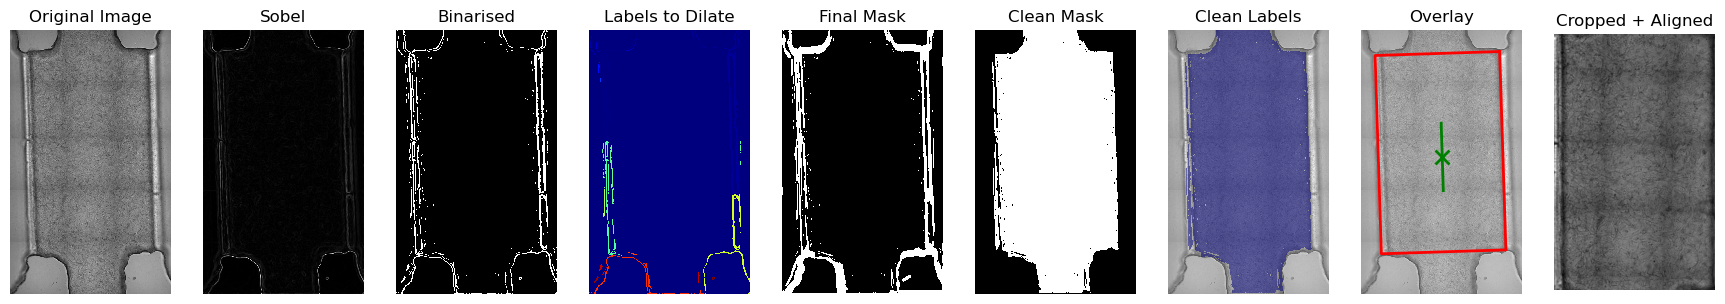

In [ ]:
unseen_image_folder = Path(r"Z:\Bel\Vascumap_Example_Lifs\training_data\downsampled_4\in_focus_each_point")
tif_files = list(unseen_image_folder.glob("*.tif"))
print(len(tif_files))
all_results = []
# for i in [1,3,7,9,15,23,45,59,91,76,89,125, 130,135,171,95,215,250,275,300]:
for i in [1]:
    if "marina" in str(tif_files[i]).lower():
        results = app.segment_device(tif_files, i, to_plot=True, mask_central_region=True)
    else:
        results = app.segment_device(tif_files, i, to_plot=True, mask_central_region=False)
    all_results.append(results)

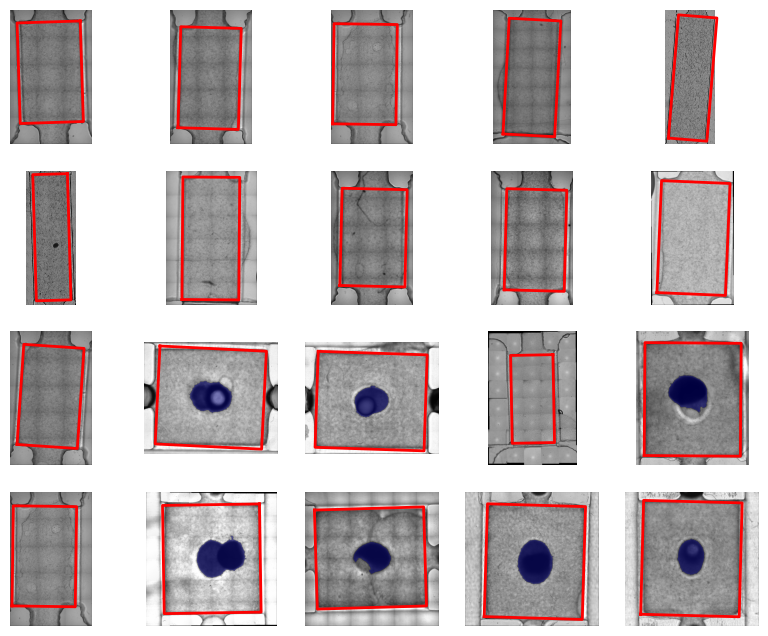

In [12]:
n = len(all_results)

# choose grid size (near-square)
ncols = int(np.ceil(np.sqrt(n)))
nrows = int(np.ceil(n / ncols))

fig, ax = plt.subplots(nrows=nrows, ncols=ncols,
figsize=(2 * ncols, 2 * nrows))

# make ax always iterable
ax = np.atleast_1d(ax).ravel()
for i, results in enumerate(all_results):
    ax[i].imshow(results[0], cmap="gray")
    if results[1] is not None:
        ax[i].imshow(np.ma.masked_where(~results[1], results[1]), cmap="jet", alpha=0.5)
    ax[i].plot(
        np.r_[results[2][:, 0], results[2][0, 0]],
    np.r_[results[2][:, 1], results[2][0, 1]],
    "-r", linewidth=2
)   

for a in ax:
    a.axis("off")
plt.savefig("selection_of_devices_3.png", transparent=True)